# `DeepTrack`
## A 4D extension of Ocetrac for volumetric tracking

### 1. Imports

In [34]:
import sys
import os

# Go up from notebooks/ to repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, repo_root)

from ocetrac.preprocessing.preprocessing import clean_binary, compute_anomalies, threshold_features
from ocetrac.preprocessing.utils import compute_dask_quantile, get_xarray_memory_usage
from ocetrac.DeepTrack import DeepTracker
from ocetrac.DeepTrack import grid, tracker
from ocetrac.preprocessing.cesm2_lens_utils import get_ds_var

In [35]:
import gc
import warnings
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings("ignore", message=".*decode the variable.*")
warnings.filterwarnings("ignore", message=".*default value for data_vars.*")

### 2. Data loading

This section loads CESM2 Large Ensemble (CESM2-LENS) ocean temperature data for a single ensemble member. The CESM2-LE provides 100 ensemble members spanning 1850-2100.
- Component: `ocn` (ocean model component POP2)
- Temporal resolution: Monthly means

In [3]:
%%time

# Select the ensemble member index
ens_memb_index = 0

# Define variable and component
# 'TEMP' = potential temperature, 'ocn' = ocean component 
# of CESM
var, comp = 'TEMP', 'ocn'

# Construct path to CESM2 Large Ensemble data on NCAR's 
# GLADE filesystem
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'

# Load historical and future projection datasets
ds_hist, ds_fut = get_ds_var(
    directory, 
    var, 
    comp, 
    ens_memb_index)

# Define latitude slice indices
# These correspond to specific grid points 
# in the ocean model's native grid
nlat_low, nlat_high = 26, 328

ds = ds_hist.TEMP.isel(
    z_t  = slice(0, 20), # Select top 20 vertical levels (surface to ~200m)
    nlat = slice(nlat_low, nlat_high), # Select latitude range using indices
).sel(time=slice('1979-01', '2015-01')) # Select time range

ds = ds.compute() # Load data from disk into memory

CPU times: user 29 s, sys: 3.35 s, total: 32.3 s
Wall time: 1min 15s


In [4]:
# Clean up future dataset to free memory
# ds_fut not needed for current analysis (only using historical period)
del ds_fut

# Force garbage collection to immediately release memory
gc.collect()
print(f"Loaded: {ds.shape}")

Loaded: (433, 20, 302, 320)


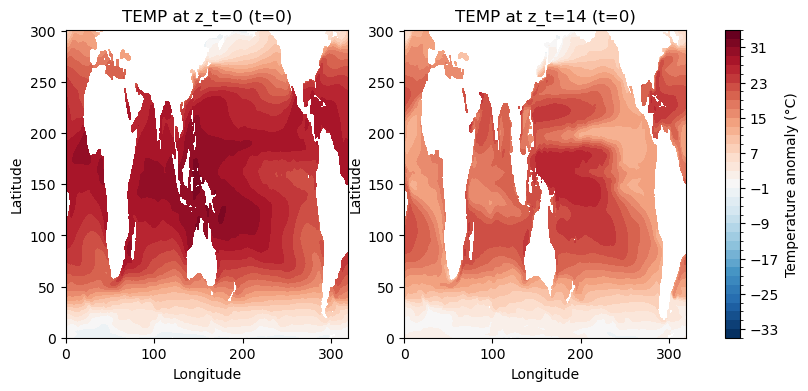

In [7]:
## -------------- Figure of temperature at different z_t
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = ds[0, 0, :, :].plot.contourf(
    ax=ax1,
    levels=36, 
    vmin=-35, 
    vmax=35, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax1.set_title('TEMP at z_t=0 (t=0)', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = ds[0, 14, :, :].plot.contourf(
    ax=ax2,
    levels=36, 
    vmin=-35, 
    vmax=35, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax2.set_title('TEMP at z_t=14 (t=0)', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Temperature anomaly (°C)', fontsize=10)
plt.show()

### 3. Anomaly computation

This preprocessing step is separate from the Ocetrac tracking algorithm. It prepares the temperature field by the trend and seasonality.

This example notebook uses `preprocessing.compute_anomalies`, which fits a 6-coefficient harmonic model per grid cell and returns the residual. `preprocessing.threshold_features` masks values below the 90th percentile.

In [5]:
%%time

anom = compute_anomalies(
    ds)

features, threshold_map = threshold_features(
    anom, 
    q=0.9) # 90th quantile 

print(f"features shape: {features.shape}  ({features.nbytes/1e9:.2f} GB)")

[########################################] | 100% Completed | 10.16 ss
[########################################] | 100% Completed | 6.63 sms
features shape: (433, 20, 302, 320)  (6.70 GB)
CPU times: user 20.8 s, sys: 2.81 s, total: 23.6 s
Wall time: 27.2 s


In [6]:
# Subset first 40 timesteps (months) for tutorial
features = features.isel(time=slice(40))

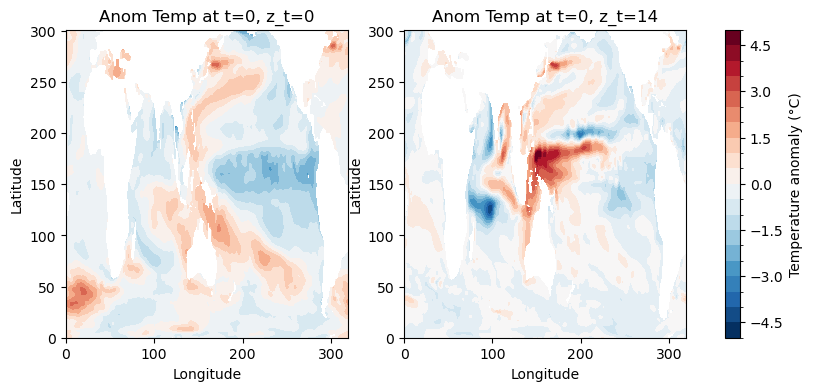

In [10]:
## -------------- Figure of anom temperature at different z_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = anom[0, 0, :, :].plot.contourf(
    ax=ax1,
    levels=21, 
    vmin=-5, 
    vmax=5, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax1.set_title('Anom Temp at t=0, z_t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = anom[0, 14, :, :].plot.contourf(
    ax=ax2,
    levels=21, 
    vmin=-5, 
    vmax=5, 
    cmap='RdBu_r',
    add_colorbar=False
)
ax2.set_title('Anom Temp at t=0, z_t=14', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Temperature anomaly (°C)', fontsize=10)

plt.show()

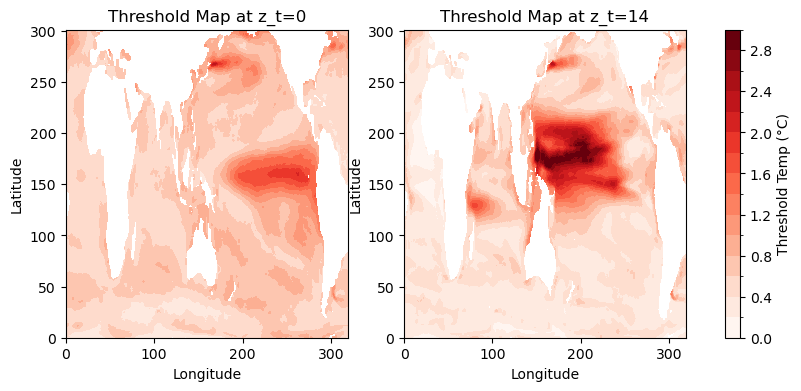

In [11]:
## -------------- Figure of threshold map at different z_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = threshold_map[0, :, :].plot.contourf(
    ax=ax1,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax1.set_title('Threshold Map at z_t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = threshold_map[14, :, :].plot.contourf(
    ax=ax2,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax2.set_title('Threshold Map at z_t=14', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Threshold Temp (°C)', fontsize=10)

plt.show()

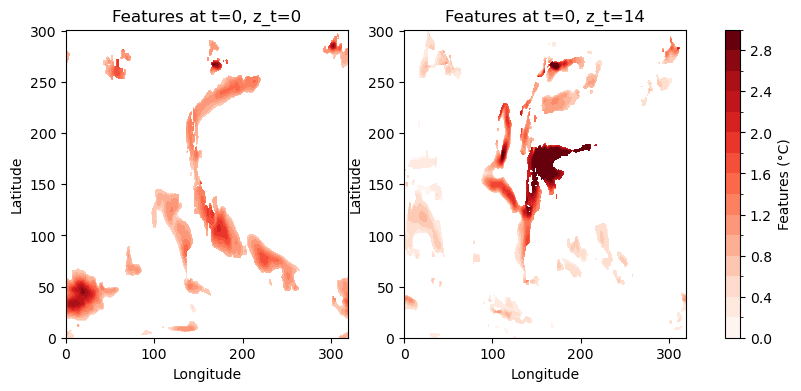

In [12]:
## -------------- Figure of 90% threshold features at different z_t

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

im1 = features[0, 0, :, :].plot.contourf(
    ax=ax1,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax1.set_title('Features at t=0, z_t=0', fontsize=12)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')

im2 = features[0, 14, :, :].plot.contourf(
    ax=ax2,
    levels=16, 
    vmin=0, 
    vmax=3, 
    cmap='Reds',
    add_colorbar=False
)
ax2.set_title('Features at t=0, z_t=14', fontsize=12)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')

cbar = plt.colorbar(im1, ax=[ax1, ax2], orientation='vertical', pad=0.05)
cbar.set_label('Features (°C)', fontsize=10)

plt.show()

### 4. Cell volume

`grid.build_cell_volume` converts TAREA (cm²) × dz (cm) → m³ per voxel. Using POP_grid.

In [7]:
%%time
grid_info   = ds_hist.isel(
    z_t=slice(0, 20), 
    nlat=slice(nlat_low, nlat_high)).sel(
    time=slice('1979-01', '2015-01'))


TAREA = grid_info.TAREA.isel(time=0)
lat = grid_info['TLAT'].values

cell_volume = grid.build_cell_volume(TAREA, 
                                     ds_hist.z_t, 
                                     n_z=20).compute()
cell_vol_np = cell_volume.values

print("cell_volume shape:", cell_volume.shape)
print("lat shape        :", lat.shape)

cell_volume shape: (20, 302, 320)
lat shape        : (302, 320)
CPU times: user 125 ms, sys: 174 μs, total: 125 ms
Wall time: 138 ms


## DeepTrack components

### Step 1 — Morphological cleaning

`preprocessing.clean_binary` runs close→open per (t, z) slice. Closing fills holes and bridges small gaps; opening removes tiny residual blobs. `radius` controls the disk size.

In [30]:
%%time
RADIUS = 3

binary_clean = clean_binary(
    features, 
    radius=RADIUS, 
    positive=True).compute()

CPU times: user 4.3 s, sys: 522 μs, total: 4.3 s
Wall time: 4.78 s


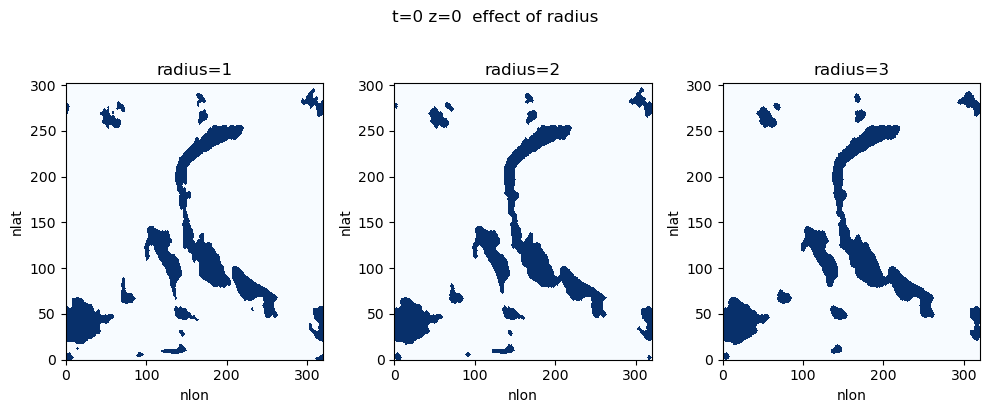

In [31]:
# Figure - Compare radii
t_check, z_check = 0, 0
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, r in zip(axes, [1, 2, 3]):
    c = clean_binary(features, radius=r, positive=True).compute()
    ax.pcolormesh(c.values[t_check, z_check].astype(int), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'radius={r}'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.suptitle(f't={t_check} z={z_check}  effect of radius', y=1.02)
plt.tight_layout(); plt.show(); plt.close()

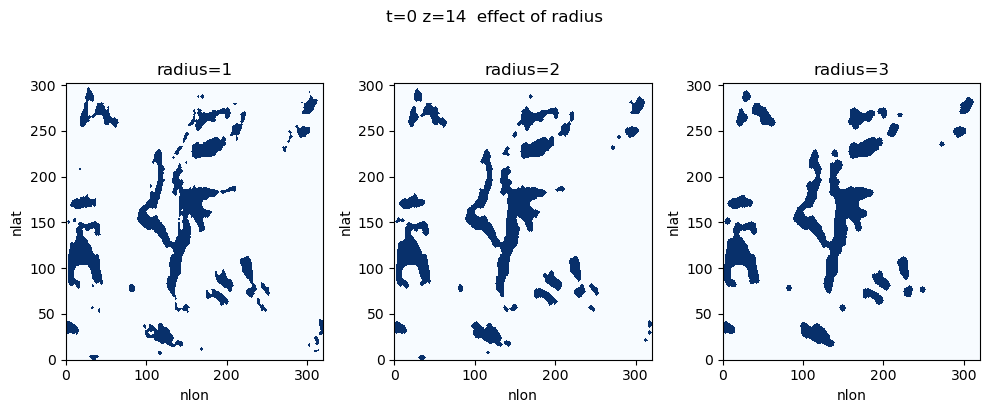

In [32]:
# Figure - Compare radii
t_check, z_check = 0, 14
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for ax, r in zip(axes, [1, 2, 3]):
    c = clean_binary(features, radius=r, positive=True).compute()
    ax.pcolormesh(c.values[t_check, z_check].astype(int), cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f'radius={r}'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.suptitle(f't={t_check} z={z_check}  effect of radius', y=1.02)
plt.tight_layout(); plt.show(); plt.close()

### Step 2 — 2-D connected-component labelling

`tracker.label_2d_stack` runs `scipy.ndimage.label` on each (t, z) slice. Background = 0.

In [36]:
%%time
labeled_2d = tracker.label_2d_stack(binary_clean)

CPU times: user 284 ms, sys: 43.9 ms, total: 327 ms
Wall time: 346 ms


2-D blobs at surface — mean: 15.1  min: 8  max: 22


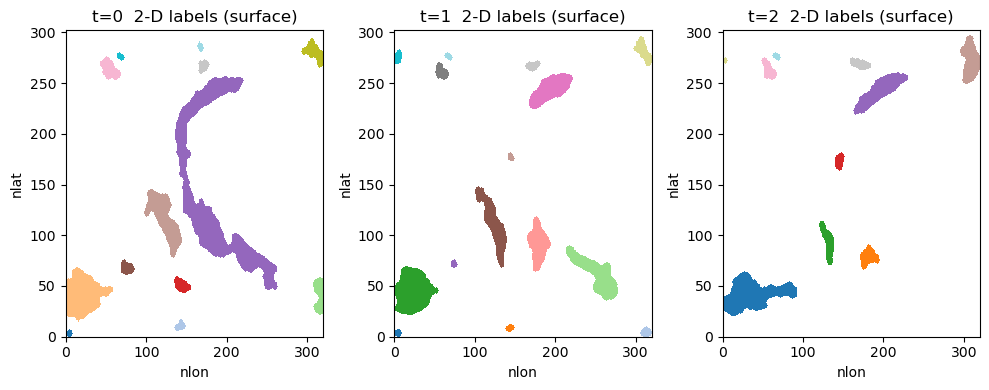

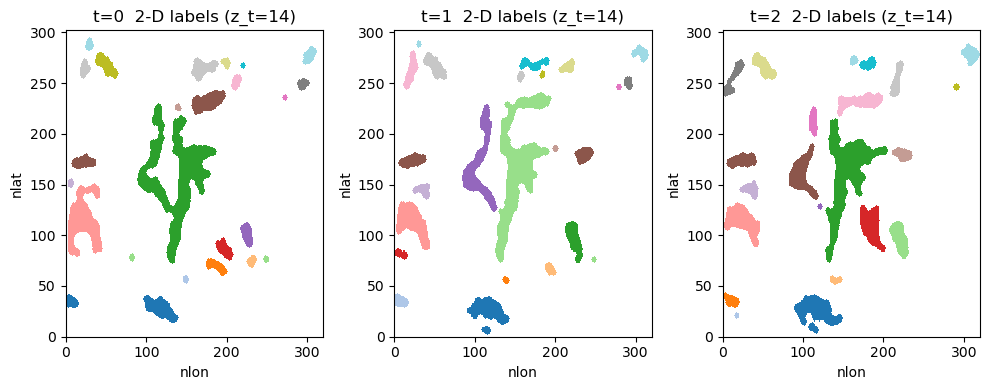

In [37]:
n_surf = [len(np.unique(labeled_2d.values[t, 0])) - 1 for t in range(labeled_2d.shape[0])]
print(f"2-D blobs at surface — mean: {np.mean(n_surf):.1f}  min: {min(n_surf)}  max: {max(n_surf)}")

labeled_2d_nan = xr.where(labeled_2d == 0, np.nan, labeled_2d)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.pcolormesh(labeled_2d_nan.values[i, 0], cmap='tab20')
    ax.set_title(f't={i}  2-D labels (surface)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.pcolormesh(labeled_2d_nan.values[i, 14], cmap='tab20')
    ax.set_title(f't={i}  2-D labels (z_t=14)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

### Step 3 — 2-D area filter

`tracker.filter_area_2d_global_depth` drops small blobs using threshold = `max(min_area_cells, percentile(all_areas_at_z, q))` computed across ALL timesteps per depth level.

In [38]:
%%time

# absolute floor: blobs with fewer than this many grid 
# cells are removed, regardless of percentile
MIN_AREA_CELLS = 200
# also drop blobs below the 25th percentile of the area 
# distribution
MIN_QUANTILE   = 0.25

filtered_np = tracker.filter_area_2d_global_depth(
    labeled_2d.values,
    min_quantile   = MIN_QUANTILE,
    min_area_cells = MIN_AREA_CELLS,
)

CPU times: user 987 ms, sys: 63.8 ms, total: 1.05 s
Wall time: 1.18 s


Total 2-D blobs before: 16140
After area filter     : 7489  (removed 8651)


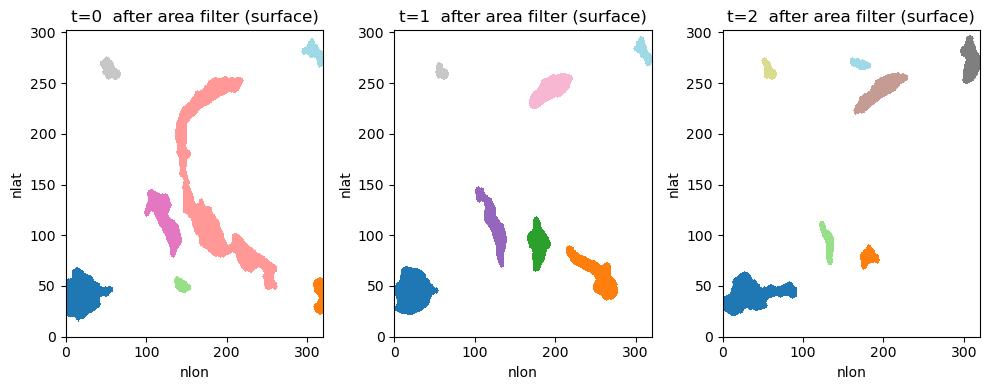

<Figure size 640x480 with 0 Axes>

In [39]:
n_before = sum(len(np.unique(labeled_2d.values[t,z]))-1
               for t in range(labeled_2d.shape[0]) for z in range(labeled_2d.shape[1]))
n_after  = sum(len(np.unique(filtered_np[t,z][filtered_np[t,z]>0]))
               for t in range(filtered_np.shape[0]) for z in range(filtered_np.shape[1]))
print(f"Total 2-D blobs before: {n_before}")
print(f"After area filter     : {n_after}  (removed {n_before - n_after})")

filtered_np_nan = xr.where(filtered_np == 0, np.nan, filtered_np)
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, ax in enumerate(axes):
    ax.pcolormesh(filtered_np_nan[i, 0], cmap='tab20')
    ax.set_title(f't={i}  after area filter (surface)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

for i, ax in enumerate(axes):
    ax.pcolormesh(filtered_np_nan[i, 14], cmap='tab20')
    ax.set_title(f't={i}  after area filter (z_t=14)'); ax.set_xlabel('nlon'); ax.set_ylabel('nlat')
plt.tight_layout(); plt.show(); plt.close()

### Step 4 — 3-D depth connectivity

`tracker.build_3d_objects` runs `scipy.ndimage.label` in 3D on each timestep's (z, nlat, nlon) volume using an anisotropic structuring element: full 8-connectivity in (lat, lon), face-only in z. Labels reset to 1..N at each timestep independently.

In [40]:
%%time

CONNECT_Z = True

# Relabel per (t,z) so IDs are compact before 3-D labelling
relabeled_np = np.zeros_like(
    filtered_np, 
    dtype=int)

for t in range(filtered_np.shape[0]):
    for z in range(filtered_np.shape[1]):
        relabeled_np[t, z] = tracker.relabel_2d(filtered_np[t, z])

struct = grid.make_anisotropic_struct(
    connect_xy=True, 
    connect_z=CONNECT_Z)

labeled_3d = tracker.build_3d_objects(
    relabeled_np, 
    struct)

CPU times: user 771 ms, sys: 108 ms, total: 878 ms
Wall time: 953 ms


connect_z=True
3-D objects per timestep — mean: 21.2  min: 13  max: 31
Total (sum across t)           : 850


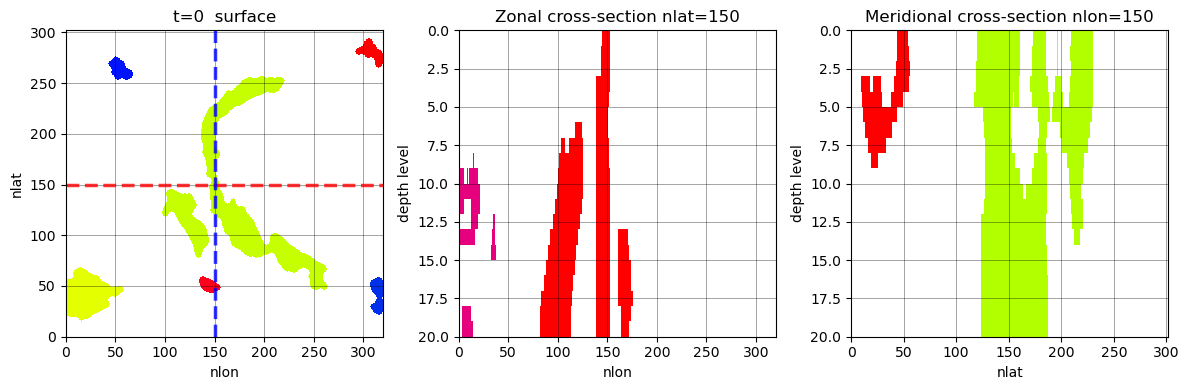

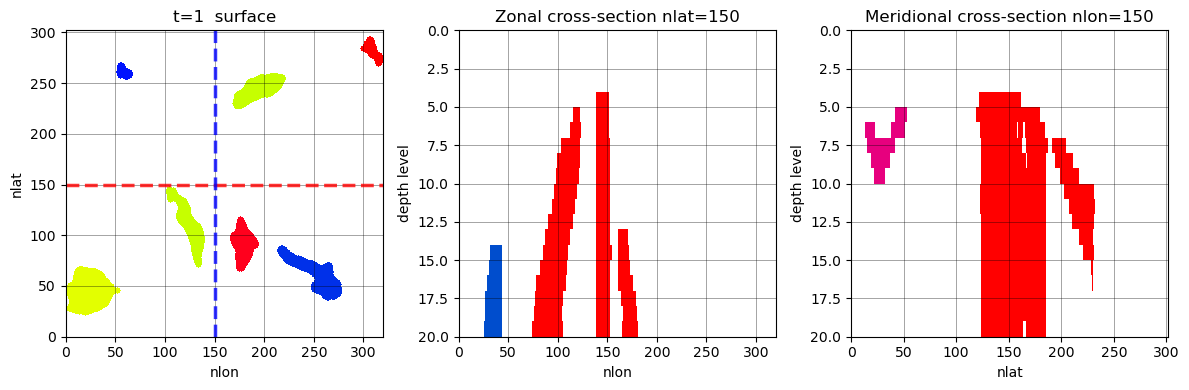

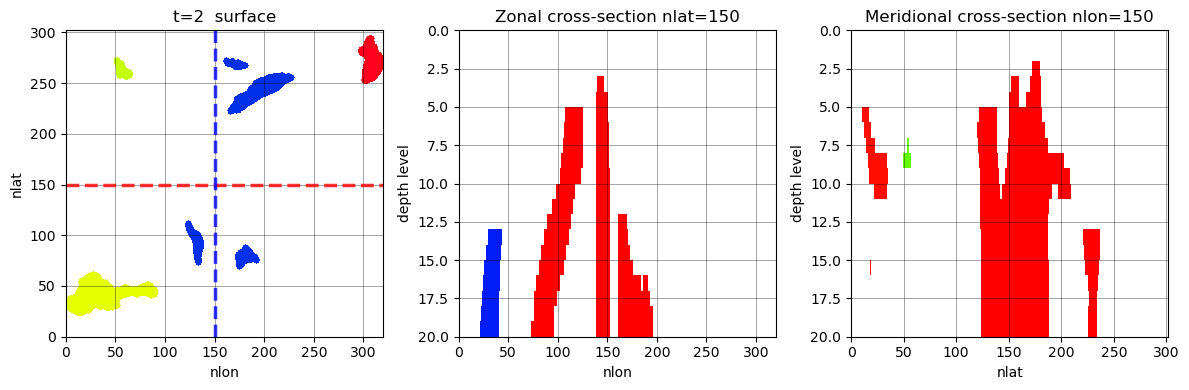

In [41]:
n_3d_per_t = [len(np.unique(labeled_3d[t][labeled_3d[t] > 0])) for t in range(labeled_3d.shape[0])]
print(f"connect_z={CONNECT_Z}")
print(f"3-D objects per timestep — mean: {np.mean(n_3d_per_t):.1f}  "
      f"min: {min(n_3d_per_t)}  max: {max(n_3d_per_t)}")
print(f"Total (sum across t)           : {sum(n_3d_per_t)}")

labeled_3d_nan = xr.where(labeled_3d == 0, np.nan, labeled_3d)

for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].pcolormesh(labeled_3d_nan[t_check, 0], vmin=0, vmax=31, cmap='prism')
    axes[0].axhline(y=150, color='red', linewidth=2.5, linestyle='--', alpha=0.8, label='Zonal section (nlat=150)')
    axes[0].axvline(x=150, color='blue', linewidth=2.5, linestyle='--', alpha=0.8, label='Meridional section (nlon=150)')
    axes[0].set_title(f't={t_check}  surface'); axes[0].set_xlabel('nlon'); axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    axes[1].pcolormesh(labeled_3d_nan[t_check, :, 150, :], vmax=31, cmap='prism')
    axes[1].invert_yaxis(); axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon'); axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    axes[2].pcolormesh(labeled_3d_nan[t_check, :, :, 150], vmax=31, cmap='prism')
    axes[2].invert_yaxis(); axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat'); axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    plt.tight_layout(); plt.show(); plt.close()

### Step 5 — Global volume filter

`tracker.filter_preserve_labels_global` drops the bottom `frac_filter` fraction of all 3-D objects by voxel count summed across ALL timesteps.

In [42]:
%%time

FRAC_FILTER = 0.25

filtered_labels = tracker.filter_preserve_labels_global(
    labeled_3d, 
    frac=FRAC_FILTER)

CPU times: user 2.82 s, sys: 91.7 ms, total: 2.91 s
Wall time: 3.26 s


In [43]:
n_pre_per_t = [len(np.unique(filtered_labels[t][filtered_labels[t] > 0])) for t in range(filtered_labels.shape[0])]
dropped     = sum(n_3d_per_t) - sum(n_pre_per_t)
print(f"After prefilter — mean per t: {np.mean(n_pre_per_t):.1f}  total: {sum(n_pre_per_t)}")
print(f"Dropped {dropped} objects ({dropped / max(sum(n_3d_per_t),1) * 100:.1f} %)")

After prefilter — mean per t: 20.4  total: 816
Dropped 34 objects (4.0 %)


In [44]:
filtered_labels_nan = xr.where(filtered_labels == 0, np.nan, filtered_labels)

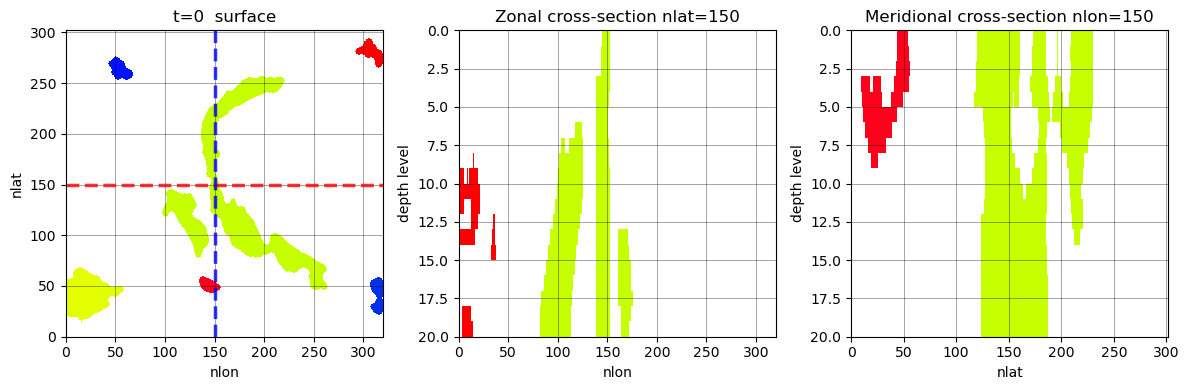

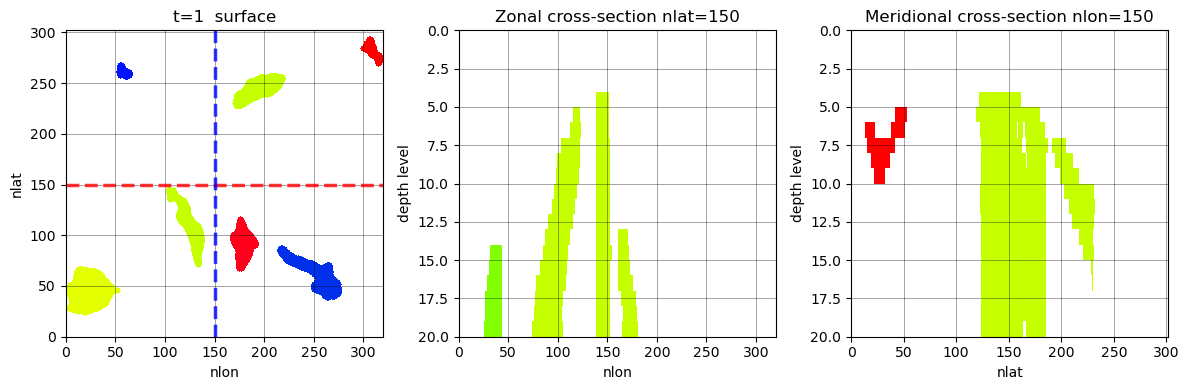

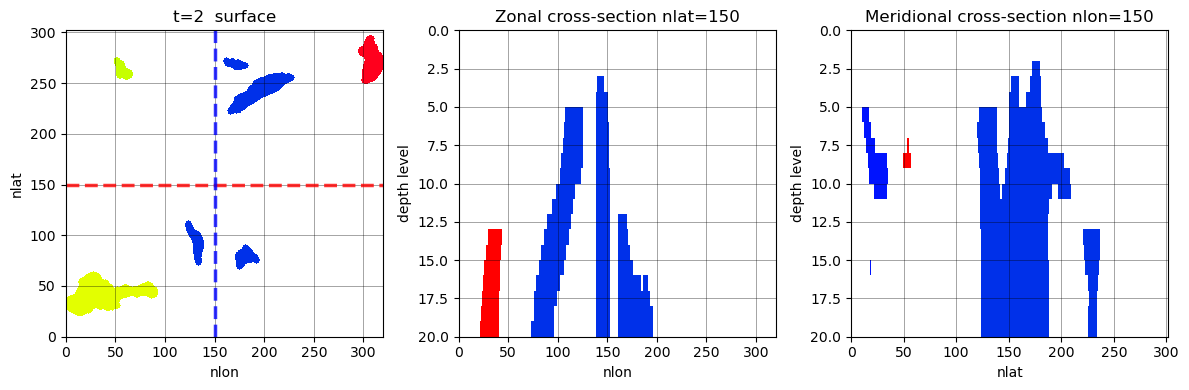

In [45]:
for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].pcolormesh(filtered_labels_nan[t_check, 0], vmin=0, vmax=31, cmap='prism')
    axes[0].axhline(y=150, color='red', linewidth=2.5, linestyle='--', alpha=0.8, label='Zonal section (nlat=150)')
    axes[0].axvline(x=150, color='blue', linewidth=2.5, linestyle='--', alpha=0.8, label='Meridional section (nlon=150)')
    axes[0].set_title(f't={t_check}  surface'); axes[0].set_xlabel('nlon'); axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    axes[1].pcolormesh(filtered_labels_nan[t_check, :, 150, :], vmin=0, vmax=31, cmap='prism')
    axes[1].invert_yaxis(); axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon'); axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    axes[2].pcolormesh(filtered_labels_nan[t_check, :, :, 150], vmin=0, vmax=31, cmap='prism')
    axes[2].invert_yaxis(); axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat'); axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    plt.tight_layout(); plt.show(); plt.close()

### Step 6 — Containment tracking with lineage preservation

`tracker.track_objects_with_splitting` links objects across time using:

```
score = max(|A∩B|/|A|, |A∩B|/|B|)
```

Dividing by the smaller object means a fragment fully contained in a parent scores 1.0, correctly linking split children. Each current object independently picks the parent with the **smallest original ID** above `contain_thresh`. Unmatched objects become new events.

In [46]:
%%time

CONTAIN_THRESH = 0.3
ALPHA = 0.5

depth_connected = filtered_labels

tracked, origin_map = tracker.track_objects_with_splitting(
    depth_connected,
    volume_weights  = cell_vol_np,
    contain_thresh  = CONTAIN_THRESH,
    alpha           = ALPHA,
    plot_results    = False,
)

CPU times: user 5.52 s, sys: 48 ms, total: 5.57 s
Wall time: 6.22 s


In [47]:
tracked_nan = xr.where(tracked == 0, np.nan, tracked)

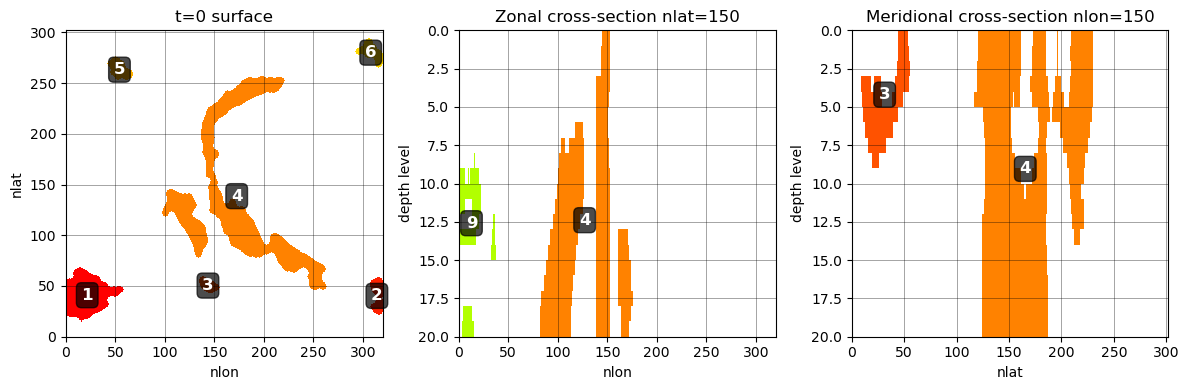

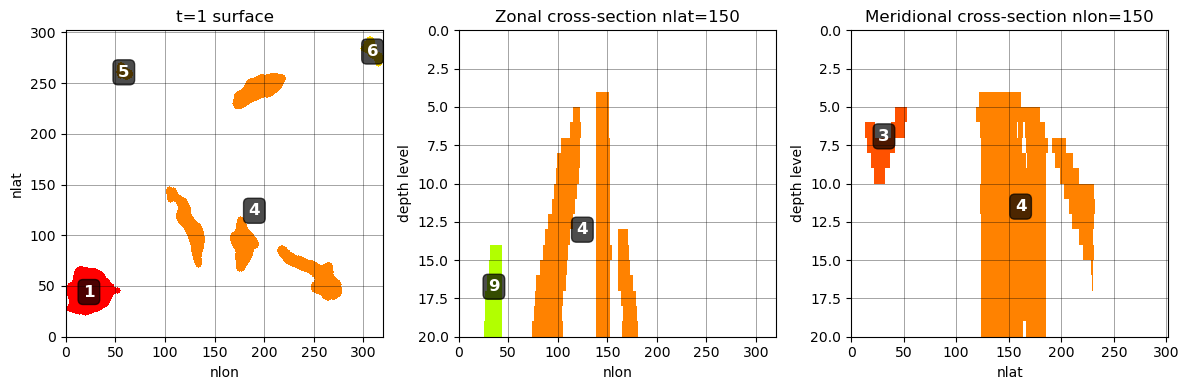

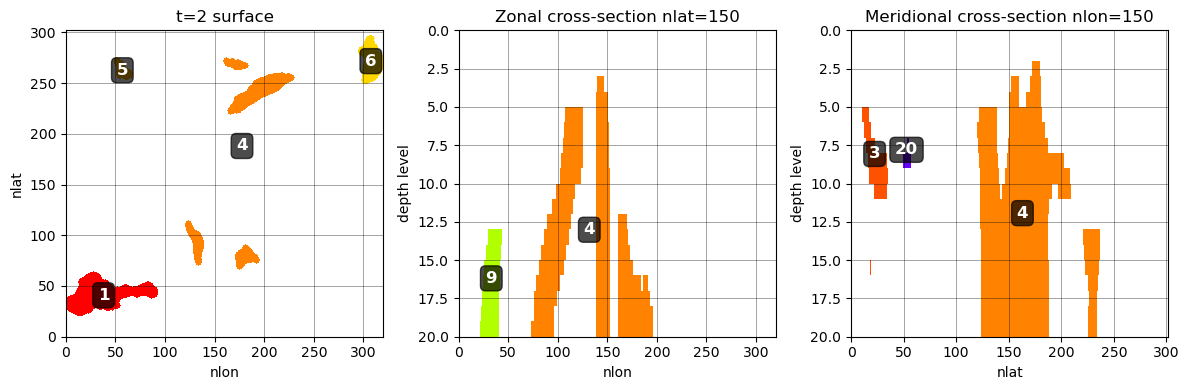

In [48]:
for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    
    # ===== SURFACE PLOT =====
    surface_data = tracked_nan[t_check, 0]
    im0 = axes[0].pcolormesh(surface_data, vmin=0, vmax=256, cmap='prism')
    axes[0].set_title(f't={t_check} surface')
    axes[0].set_xlabel('nlon')
    axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object on surface
    unique_ids = np.unique(surface_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (surface_data == obj_id)
        if mask.any():
            # Get centroid of the object
            y_center, x_center = np.mean(np.where(mask), axis=1)
            # Get the actual object label
            obj_label = int(obj_id)
            axes[0].text(x_center, y_center, str(obj_label), 
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== ZONAL CROSS-SECTION =====
    zonal_data = tracked_nan[t_check, :, 150, :]
    im1 = axes[1].pcolormesh(zonal_data, vmin=0, vmax=256, cmap='prism')
    axes[1].invert_yaxis()
    axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon')
    axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in zonal section
    unique_ids = np.unique(zonal_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (zonal_data == obj_id)
        if mask.any():
            # Get centroid (depth, lon)
            z_center, x_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[1].text(x_center, z_center, str(obj_label), 
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== MERIDIONAL CROSS-SECTION =====
    merid_data = tracked_nan[t_check, :, :, 150]
    im2 = axes[2].pcolormesh(merid_data, vmin=0, vmax=256, cmap='prism')
    axes[2].invert_yaxis()
    axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat')
    axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in meridional section
    unique_ids = np.unique(merid_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (merid_data == obj_id)
        if mask.any():
            # Get centroid (depth, lat)
            z_center, y_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[2].text(y_center, z_center, str(obj_label), 
                        color='white', fontsize=12, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
        
    plt.tight_layout()
    plt.show()
    plt.close()

### Dropout summary

In [49]:
n_2d    = sum(len(np.unique(labeled_2d.values[t,z]))-1
              for t in range(labeled_2d.shape[0]) for z in range(labeled_2d.shape[1]))
n_3d    = sum(n_3d_per_t)
n_pre   = sum(n_pre_per_t)
n_final = len(np.unique(tracked_nan.data))-1

print(f"2-D blobs (all t, all z)   : {n_2d:>6}")
print(f"After 3-D labelling        : {n_3d:>6}  (area filter removed small blobs)")
print(f"After global filter        : {n_pre:>6}  (dropped {n_3d - n_pre})")
print(f"After containment tracking : {n_final}")

2-D blobs (all t, all z)   :  16140
After 3-D labelling        :    850  (area filter removed small blobs)
After global filter        :    816  (dropped 34)
After containment tracking : 256


# OR RUN EVERYTHING VIA DeepTracker

The `DeepTracker` class wraps the entire pipeline in one call.

In [50]:
%%time

tracker = DeepTracker(
    features,
    radius         = 3,
    min_area_cells = 200,
    min_quantile   = 0.25, 
    contain_thresh = 0.3,
    alpha          = 0.5,
    frac_filter    = 0.25,
    connect_z      = True,
    positive       = True,
    n_z            = 20,
)
result_full = tracker.run(cell_volume=cell_vol_np)
tracker.summary()

Step 1 · morphological cleaning …
    fraction flagged warm = 0.0899  (OK)
Step 2 · 2-D connected-component labelling …
    surface blobs — mean=15.1  min=8  max=22
Step 3a · area filtering …
    2-D blobs: 16,140 → 7,489  (removed 8,651)
Step 3b · 3-D depth connectivity …
    3-D objects/timestep — mean=21.2  min=13  max=31  total=850
Step 4 · global volume filter …
    3-D objects: 850 → 816  (removed 34)
Step 5 · containment tracking …
    unique event IDs assigned: 256
Step 6 · wrapping result …
    final events: 256
DeepTracker — Result Summary
  Input shape    : (40, 20, 302, 320)
  Tracked events : 256
  Duration  min/median/max : 1 / 1 / 40
    >=  1 ts : 256
    >=  3 ts : 49
    >=  6 ts : 16
    >= 12 ts : 6

  Parameters:
    radius           = 3
    min_area_cells   = 200
    min_quantile     = 0.25
    frac_filter      = 0.25
    contain_thresh   = 0.3
    alpha            = 0.5
    connect_z        = True
CPU times: user 16.5 s, sys: 566 ms, total: 17 s
Wall time: 19.7 s

In [51]:
result_xr = xr.DataArray(
    result_full, 
    dims=features.dims, 
    coords=features.coords,
    name='events_tracked')
# result_xr.to_netcdf('deeptrack_events.nc')

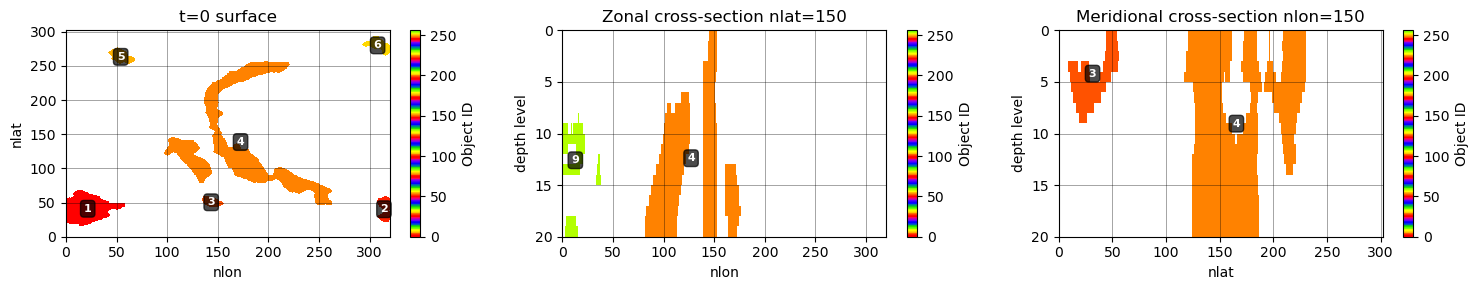

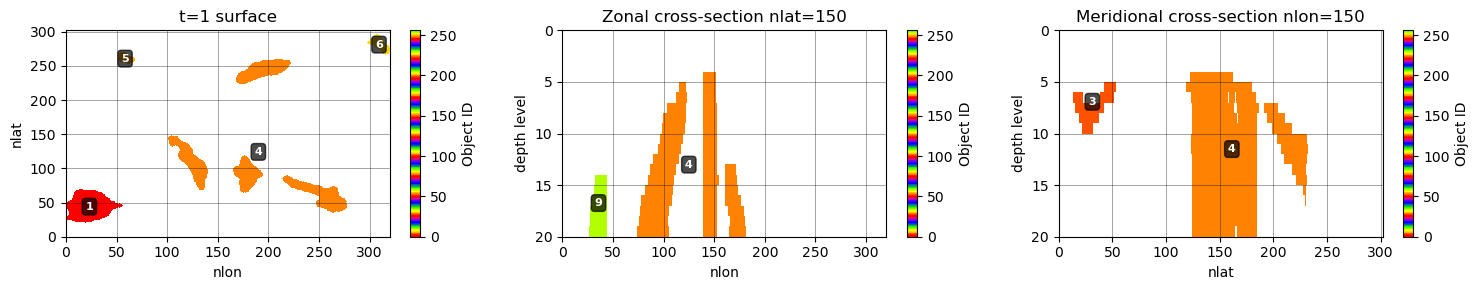

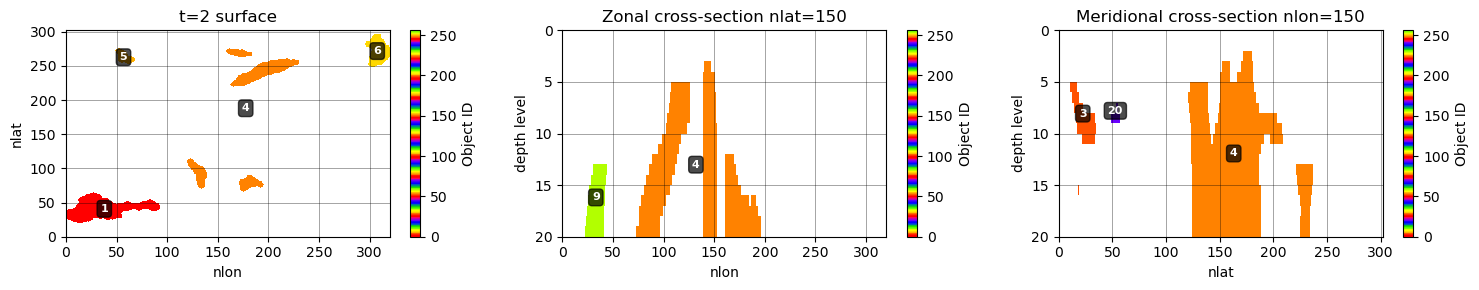

In [52]:
for t_check in range(3):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    
    # ===== SURFACE PLOT =====
    surface_data = result_xr[t_check, 0]
    im0 = axes[0].pcolormesh(surface_data, vmin=0, vmax=256, cmap='prism')
    axes[0].set_title(f't={t_check} surface')
    axes[0].set_xlabel('nlon')
    axes[0].set_ylabel('nlat')
    axes[0].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object on surface
    unique_ids = np.unique(surface_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (surface_data == obj_id)
        if mask.any():
            # Get centroid of the object
            y_center, x_center = np.mean(np.where(mask), axis=1)
            # Get the actual object label
            obj_label = int(obj_id)
            axes[0].text(x_center, y_center, str(obj_label), 
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== ZONAL CROSS-SECTION =====
    zonal_data = result_xr[t_check, :, 150, :]
    im1 = axes[1].pcolormesh(zonal_data, vmin=0, vmax=256, cmap='prism')
    axes[1].invert_yaxis()
    axes[1].set_title('Zonal cross-section nlat=150')
    axes[1].set_xlabel('nlon')
    axes[1].set_ylabel('depth level')
    axes[1].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in zonal section
    unique_ids = np.unique(zonal_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (zonal_data == obj_id)
        if mask.any():
            # Get centroid (depth, lon)
            z_center, x_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[1].text(x_center, z_center, str(obj_label), 
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    # ===== MERIDIONAL CROSS-SECTION =====
    merid_data = result_xr[t_check, :, :, 150]
    im2 = axes[2].pcolormesh(merid_data, vmin=0, vmax=256, cmap='prism')
    axes[2].invert_yaxis()
    axes[2].set_title('Meridional cross-section nlon=150')
    axes[2].set_xlabel('nlat')
    axes[2].set_ylabel('depth level')
    axes[2].grid(True, color='k', linewidth=0.5, alpha=0.5)
    
    # Add labels for each object in meridional section
    unique_ids = np.unique(merid_data)
    unique_ids = unique_ids[unique_ids > 0]
    for obj_id in unique_ids:
        mask = (merid_data == obj_id)
        if mask.any():
            # Get centroid (depth, lat)
            z_center, y_center = np.mean(np.where(mask), axis=1)
            obj_label = int(obj_id)
            axes[2].text(y_center, z_center, str(obj_label), 
                        color='white', fontsize=8, fontweight='bold',
                        ha='center', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
    
    plt.colorbar(im0, ax=axes[0], label='Object ID')
    plt.colorbar(im1, ax=axes[1], label='Object ID')
    plt.colorbar(im2, ax=axes[2], label='Object ID')
    
    plt.tight_layout()
    plt.show()
    plt.close()

# Plotting 3D plots of events

In [53]:
from ocetrac.plotting.DeepTrack_plot_utils import plot_3d_labeled_feature


Plotting feature 5 at time 0
Applied Gaussian smoothing (sigma=0.5)
Extracted surface: 3167 vertices, 6110 faces


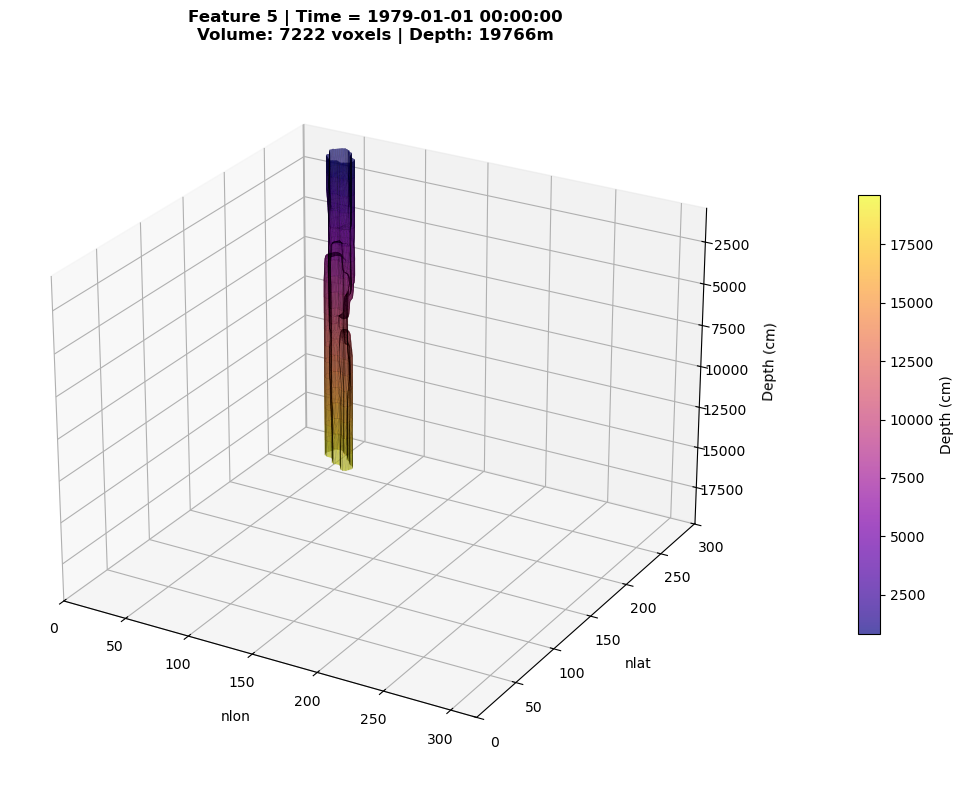


Plotting feature 5 at time 1
Applied Gaussian smoothing (sigma=0.5)
Extracted surface: 2997 vertices, 5794 faces


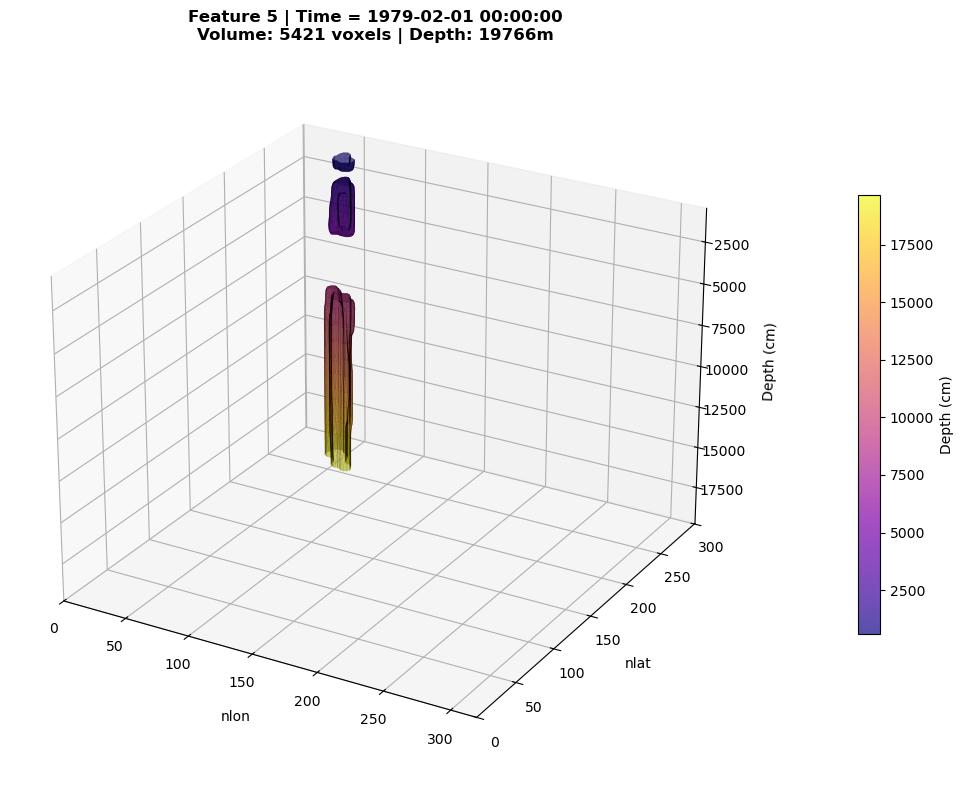


Plotting feature 5 at time 2
Applied Gaussian smoothing (sigma=0.5)
Extracted surface: 2934 vertices, 5654 faces


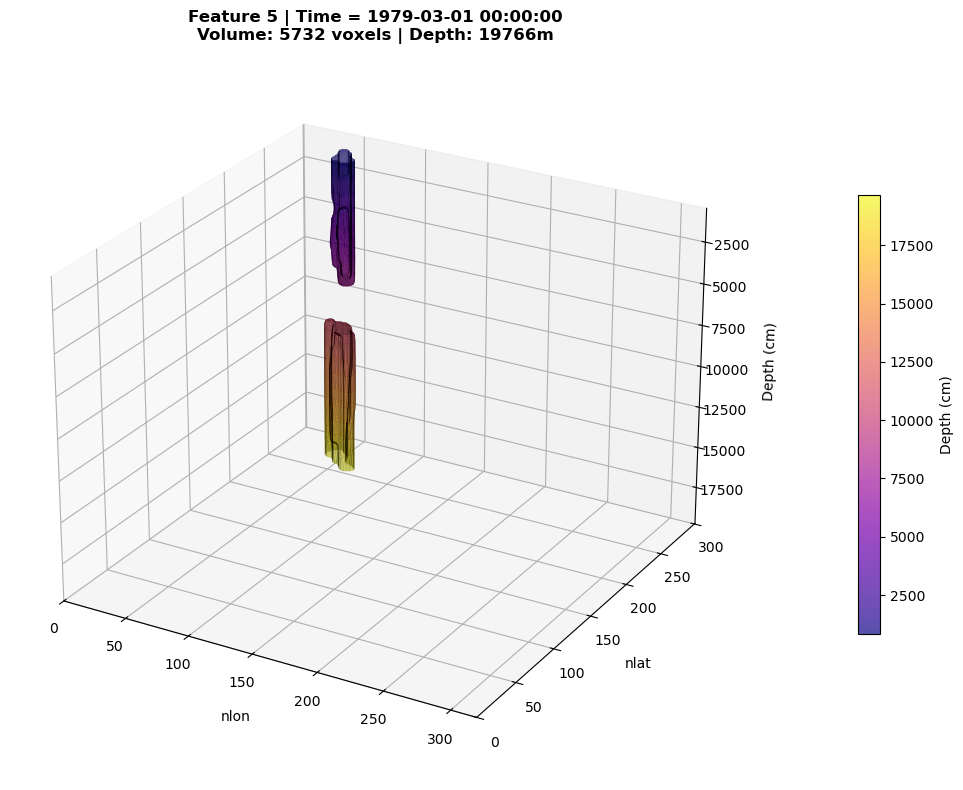

In [57]:
for time_idx in range(3):
    print(f"\n{'='*50}")
    print(f"Plotting feature 5 at time {time_idx}")
    print(f"{'='*50}")
    
    fig, ax = plot_3d_labeled_feature(
        result_xr, 
        feature_id=5, 
        time_idx=time_idx,
        threshold=0.5,
        sigma=0.5,  # Slight smoothing for cleaner surface
        alpha=0.7,
        cmap='plasma',
        elev=25,
        azim=-60,
        figsize=(12, 8)
    )
    
    if fig is not None:
        plt.show()
        plt.close(fig)


Plotting feature 1 at time 5
Applied Gaussian smoothing (sigma=0.2)
Extracted surface: 11367 vertices, 22190 faces


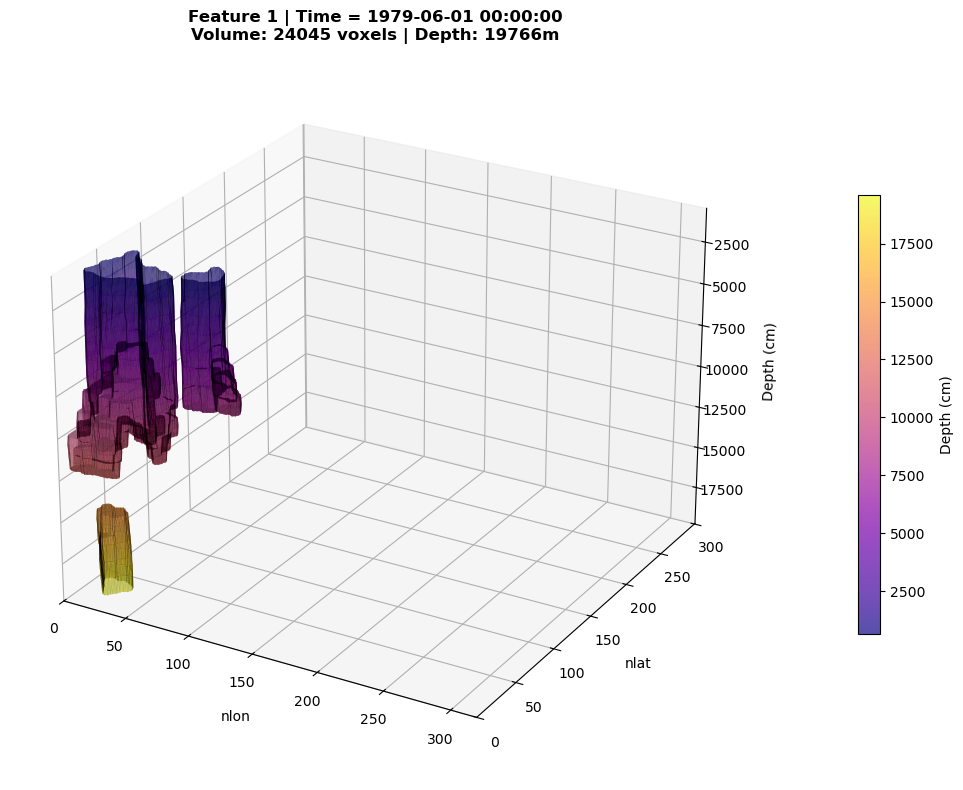


Plotting feature 1 at time 6
Applied Gaussian smoothing (sigma=0.2)
Extracted surface: 13798 vertices, 27170 faces


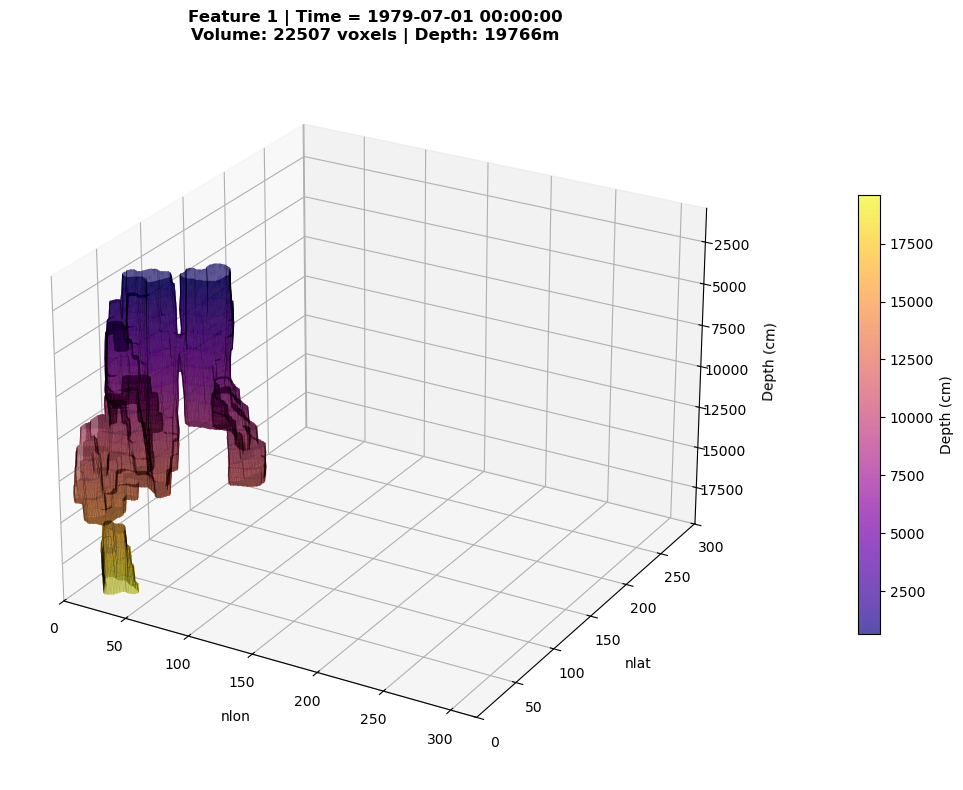


Plotting feature 1 at time 7
Applied Gaussian smoothing (sigma=0.2)
Extracted surface: 13880 vertices, 27280 faces


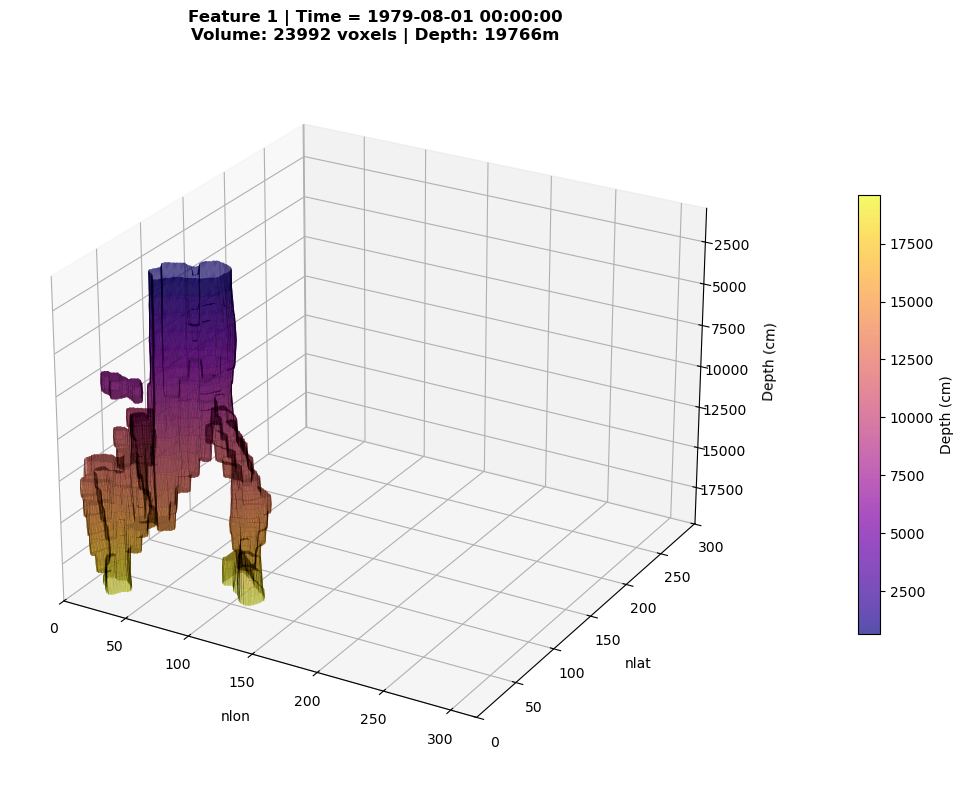

In [58]:
for time_idx in range(5,8):
    print(f"\n{'='*50}")
    print(f"Plotting feature 1 at time {time_idx}") # also 4 is interested
    print(f"{'='*50}")
    
    fig, ax = plot_3d_labeled_feature(
        result_xr, 
        feature_id=1, 
        time_idx=time_idx,
        threshold=0.5,
        sigma=0.2,  # Slight smoothing for cleaner surface
        alpha=0.7,
        cmap='plasma',
        elev=25,
        azim=-60,
        figsize=(12, 8)
    )
    
    if fig is not None:
        plt.show()
        plt.close(fig)